# Demo of DISC tomography based on a surface geometry for active seismic dataset

## Description
This notebook implements DISC based on a surface geometry for active seismic dataset.
It is designed for generating synthetic data, performing ray path matrix reconstruction, and updating velocity models through gradient-based optimization.


## Date
2026-07

In [1]:
#####Step1 import necessary package
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import lsqr
import sys
from pyekfmm import eikonal,ray2d2  #extract traveltime and ray tracing (new) functions from pyekfmm
from pyseistr.solvers import solver,conjgrad
from pyseistr.solvers import cgstep
from pyseistr.operators import adjnull,matrix_lop
from pyseistr.divne import trianglen_lop
from scipy.ndimage import gaussian_filter
import os

In [2]:
#####Step2 create real Marmousi model
address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

vel1=address+'/data/marmousi_portion.npy'
v_true=np.load(vel1)[15:36,:]

print(v_true.shape)

ny, nx = v_true.shape  ###model size  ny means nz
dx = dy =0.2      ###spacing rinterval

#########geometry setting
n_sources = 20 ####number of sources
sources = [((i*(nx-1)*dx/(n_sources-1)),0) for i in range(n_sources)] #### source locations (x,y)
n_receivers =216   ####number of recevivers
receivers = [((i*(nx-1)*dx/(n_receivers-1)),0) for i in range(n_receivers)] ### receiver locations (x,y)


(21, 216)


In [3]:
#####Step3 build ray path matrix based on eikonal wave equation
sources_x=[ii[0] for ii in sources] ########x coordinates of sources
sources_y=[ii[1] for ii in sources] ########y coordinates of sources

receivers_x=[ii[0] for ii in receivers] ########x coordinates of receivers
receivers_y=[ii[1] for ii in receivers] ########y coordinates of receivers

address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

from disc.raytrace import * ####import necessary functions for traveltime and ray path calculation  

###compute traveltime for each ray based on eikonal equation
traveltimes,ray_paths=compute_travel_times(v_true, sources, receivers, dx, dy, nx, ny, 1)  

###build ray path matrix 
A=build_ray_matrix(ray_paths, dx, dy, nx, ny, 0)


obst=(np.squeeze(traveltimes))  ####observed traveltime from Eikonal equation

nd=len(obst) #####length of traveltime vector

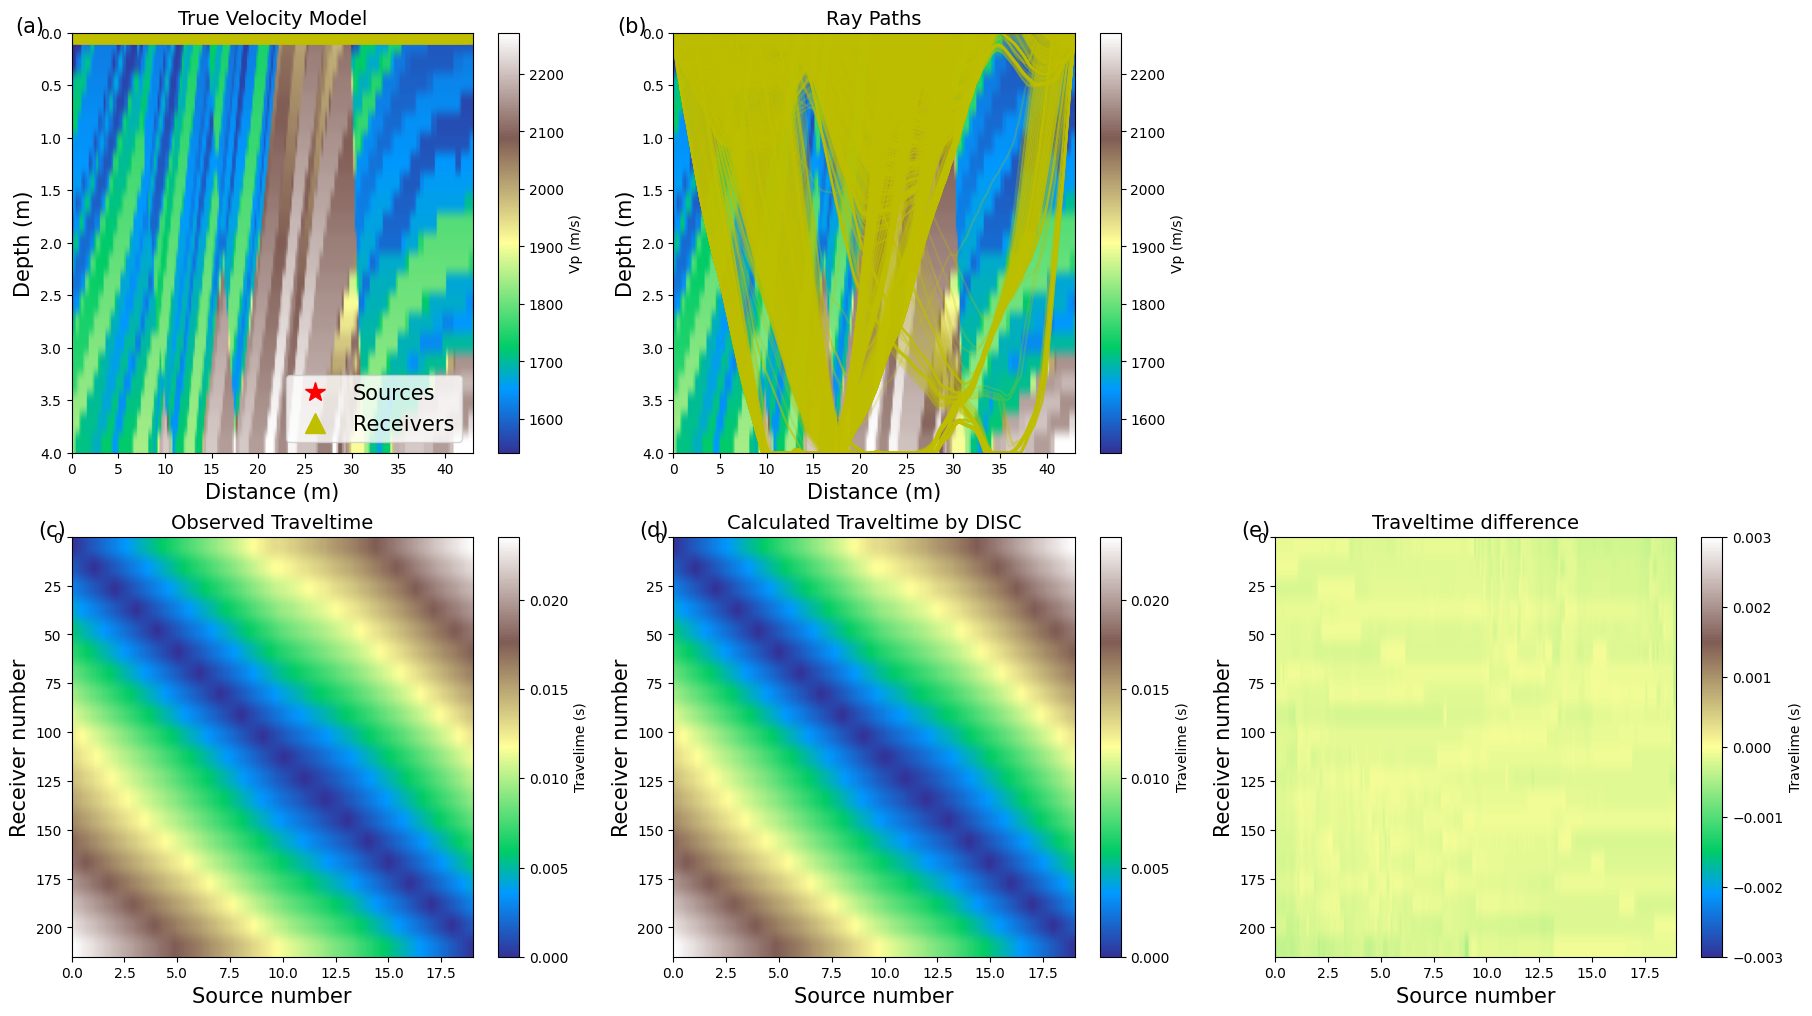

In [4]:
########Step 4 observed travel time comparison

time_eik=np.squeeze(traveltimes).reshape(np.array(sources).shape[0],np.array(receivers).shape[0])#traveltime estimated usig eikonal equation

time_cal=A.dot(1./v_true.reshape(nx*ny,1,order='C')).reshape(np.array(sources).shape[0],np.array(receivers).shape[0]) #### traveltime calculated using ray path matrix and true velocity model

v_low = v_true.min()
v_hig = v_true.max()



tlow=time_eik.min()
thig=time_eik.max()

plt.figure(figsize=(22,12))
plt.subplot(2,3,1)
plt.imshow(v_true,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-6,0, '(a)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
plt.plot(sources_x,sources_y,'r*',  markersize=15)
plt.plot(receivers_x,receivers_y,'y^',  markersize=15)
plt.title('True Velocity Model', fontsize=14)
plt.legend(['Sources','Receivers'],loc='lower right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})

plt.subplot(2,3,2)
plt.imshow(v_true,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-6,0, '(b)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
for ray_x, ray_y in ray_paths:
    plt.plot(ray_x, ray_y, 'y-', alpha=0.25)
plt.title('Ray Paths', fontsize=14)

plt.subplot(2,3,4)
plt.imshow(time_eik,cmap='terrain',vmin=tlow,vmax=thig,extent=[0,(n_sources-1),(n_receivers-1),0],aspect='auto')
plt.ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 	 
plt.text(-1.6,0, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Travelime (s)')
plt.title('Observed Traveltime', fontsize=14)

plt.subplot(2,3,5)
plt.imshow(time_eik,cmap='terrain',vmin=tlow,vmax=thig,extent=[0,(n_sources-1),(n_receivers-1),0],aspect='auto')
plt.ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 	 
plt.text(-1.6,0, '(d)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Travelime (s)')
plt.title('Calculated Traveltime by DISC', fontsize=14)


plt.subplot(2,3,6)
plt.imshow(time_eik-time_cal,cmap='terrain',vmin=-0.003,vmax=0.003,extent=[0,(n_sources-1),(n_receivers-1),0],aspect='auto')
plt.ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 	 
plt.text(-1.6,0, '(e)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Travelime (s)')
plt.title('Traveltime difference', fontsize=14)

plt.show()
	

In [5]:
########Step 5 tomography inversion using DISC method
oniter=20  ####number of outer iteration
initer=8  ####number of inner iteration

vinit = 1 / (gaussian_filter(1 / v_true, 30)) #####initialize starting model

v_disc=vinit

for i in range(oniter):
	_,ray_pathsini=compute_travel_times(v_disc, sources, receivers, dx, dy, nx, ny, 1)   ###ray traceing based on the given model
	opsr=build_ray_matrix(ray_pathsini, dx, dy, nx, ny)  ####build ray path matrix using the initial model

	nm=opsr.toarray().shape[1] 
	par_S={'nm':nm,'nd':nm,'nbox':[5,5,1],'ndat':[nx,ny,1],'ndim':3} ### shaping operator setting
	v_disc=tomoloop(v_disc,opsr,initer,nx,ny,nd,obst,par_S) ### gradient estimation and model update

	v_disc = np.clip(v_disc, v_low, v_hig)
	
	print('iter=',i+1,msecal(obst,np.matmul(opsr.toarray(),1./v_disc.flatten(order='C'))))


iter= 1 5.461478460812005e-08
iter= 2 5.0470342097946e-08
iter= 3 4.157462403432733e-08
iter= 4 4.541397989550561e-08
iter= 5 4.209471369937914e-08
iter= 6 3.8278709144145564e-08
iter= 7 3.6072576763021565e-08
iter= 8 3.298071260911685e-08
iter= 9 3.012196460883537e-08
iter= 10 2.7847193397680195e-08
iter= 11 2.5925662711093243e-08
iter= 12 2.2556771297178854e-08
iter= 13 2.1304750120294293e-08
iter= 14 1.867560385854769e-08
iter= 15 1.723615215002141e-08
iter= 16 1.630522349366114e-08
iter= 17 1.4368558824550854e-08
iter= 18 1.3436987125726737e-08
iter= 19 1.2286725473991914e-08
iter= 20 1.139135523799323e-08


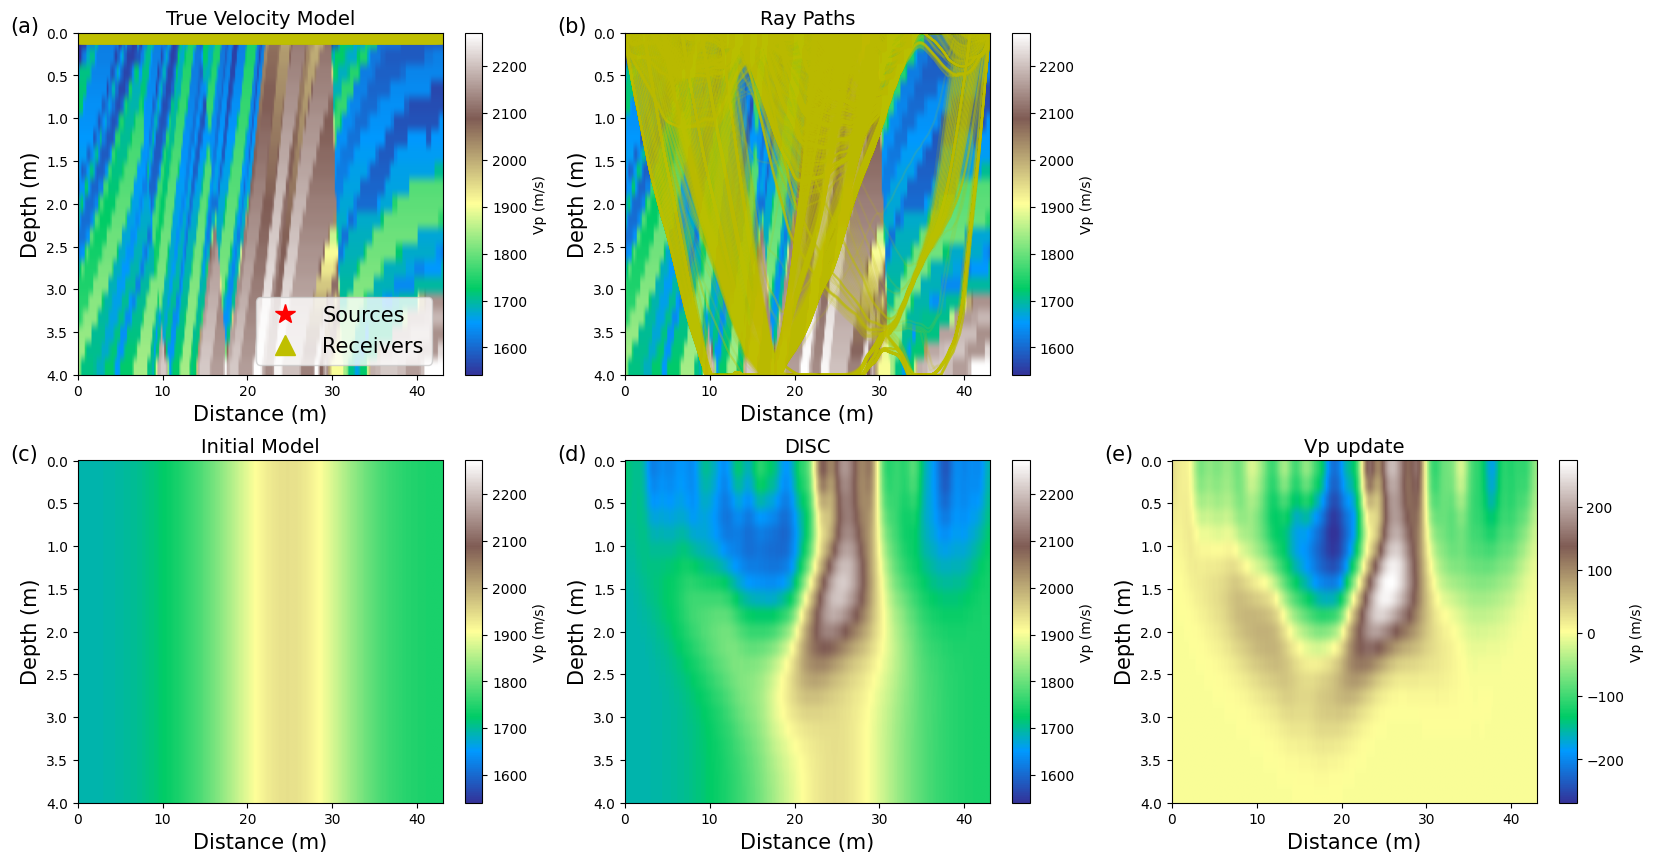

In [ ]:
figadd=address+'/Figure/'
plt.figure(figsize=(20,10))
plt.subplot(2,3,1)
plt.imshow(v_true,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-8,0, '(a)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
plt.plot(sources_x,sources_y,'r*',  markersize=15)
plt.plot(receivers_x,receivers_y,'y^',  markersize=15)
plt.title('True Velocity Model', fontsize=14)
plt.legend(['Sources','Receivers'],loc='lower right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})

plt.subplot(2,3,2)
plt.imshow(v_true,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-8,0, '(b)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
for ray_x, ray_y in ray_paths:
    plt.plot(ray_x, ray_y, 'y-', alpha=0.15)
plt.title('Ray Paths', fontsize=14)

plt.subplot(2,3,4)
plt.imshow(vinit,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-8,0, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
plt.title('Initial Model', fontsize=14)

plt.subplot(2,3,5)
plt.imshow(v_disc,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-8,0, '(d)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
plt.title('DISC', fontsize=14)

plt.subplot(2,3,6)
plt.imshow(v_disc-vinit,cmap='terrain',extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.text(-8,0, '(e)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
plt.colorbar(label='Vp (m/s)')
plt.title('Vp update', fontsize=14)

plt.subplots_adjust(hspace=0.25)
# plt.savefig(figadd+"marm_surface.png", dpi=300,bbox_inches='tight')	
plt.show()